In [1]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

# This import is needed to load the AirPassengers dataset
from statsmodels.datasets import get_rdataset
import warnings
warnings.filterwarnings("ignore")
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [7]:
# --- Section 1: Loading a Real-World Non-Stationary Time Series ---
# We will use the classic 'AirPassengers' dataset, which records the number
# of international airline passengers from 1949 to 1960.
# It has both a clear upward trend and a seasonal pattern.
print("Loading the 'AirPassengers' dataset...")

# Load the dataset from statsmodels
air_passengers_data = get_rdataset("AirPassengers", "datasets")
non_stationary_series = air_passengers_data.data['value']
non_stationary_series.index = pd.to_datetime(
    pd.date_range(start='1949-01-01', end='1960-12-01', freq='MS')
)

Loading the 'AirPassengers' dataset...


In [8]:
non_stationary_series

1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Freq: MS, Name: value, Length: 144, dtype: int64

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121
...,...,...
139,1960.583333,606
140,1960.666667,508
141,1960.750000,461
142,1960.833333,390


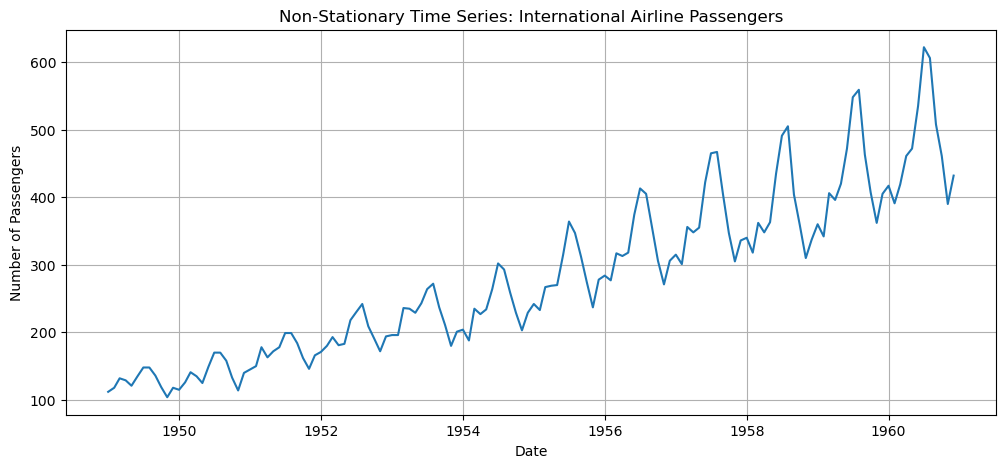

In [9]:
# Plot the original series to visually confirm its non-stationarity
plt.figure(figsize=(12, 5))
plt.plot(non_stationary_series)
plt.title('Non-Stationary Time Series: International Airline Passengers')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.grid(True)
plt.show()

In [10]:
def check_stationarity(series, test_name):
    """
    Performs and prints the results of the ADF and KPSS tests.
    
    Args:
        series (pd.Series): The time series to test.
        test_name (str): A descriptive name for the series being tested.
    """
    print(f"\n--- Results for the {test_name} series ---")
    
    # Augmented Dickey-Fuller (ADF) Test
    # H0: The series is non-stationary (has a unit root)
    adf_result = adfuller(series)
    print("ADF Test:")
    print(f"  Test Statistic: {adf_result[0]:.4f}")
    print(f"  P-value: {adf_result[1]:.4f}")
    print("  Interpretation:")
    if adf_result[1] > 0.05:
        print("  --> Fails to reject H0. The series is likely non-stationary.")
    else:
        print("  --> Rejects H0. The series is likely stationary.")
    
    # Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test
    # H0: The series is stationary
    try:
        kpss_result = kpss(series, regression='c')
        print("\nKPSS Test:")
        print(f"  Test Statistic: {kpss_result[0]:.4f}")
        print(f"  P-value: {kpss_result[1]:.4f}")
        print("  Interpretation:")
        if kpss_result[1] < 0.05:
            print("  --> Rejects H0. The series is likely non-stationary.")
        else:
            print("  --> Fails to reject H0. The series is likely stationary.")
    except Exception as e:
        print("\nKPSS Test could not be performed due to an error:")
        print(f"  Error: {e}")

In [11]:
# Run the tests on the original non-stationary series
check_stationarity(non_stationary_series, 'Original Non-Stationary')


--- Results for the Original Non-Stationary series ---
ADF Test:
  Test Statistic: 0.8154
  P-value: 0.9919
  Interpretation:
  --> Fails to reject H0. The series is likely non-stationary.

KPSS Test:
  Test Statistic: 1.6513
  P-value: 0.0100
  Interpretation:
  --> Rejects H0. The series is likely non-stationary.


Text(0.5, 0.98, 'ACF and PACF of Original Non-Stationary Series')

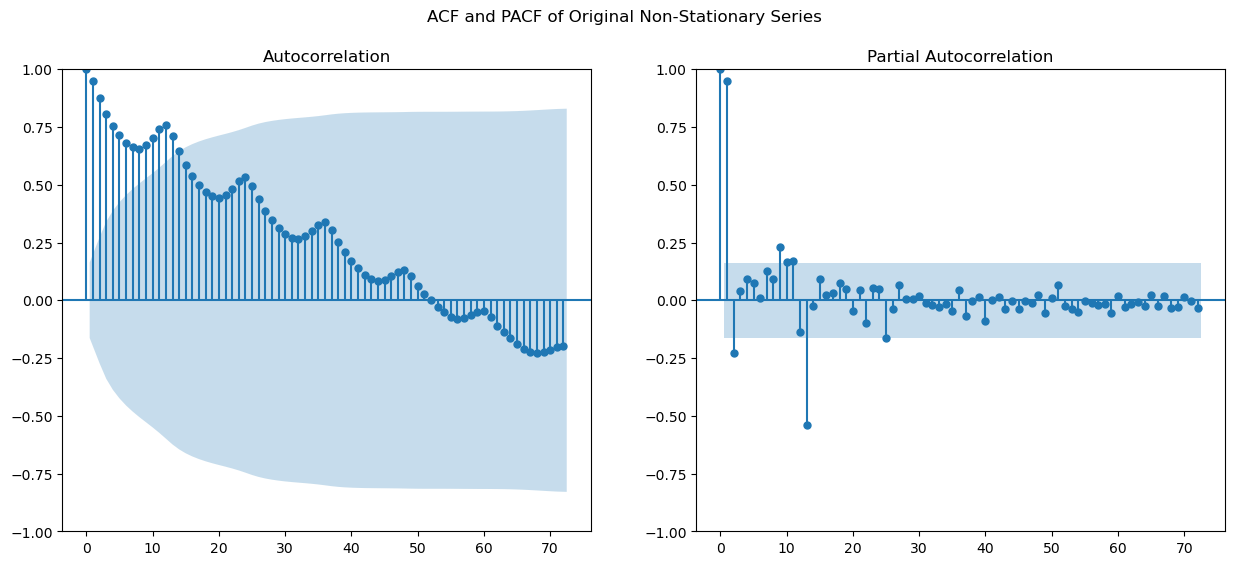

In [14]:
# Plot for the original, non-stationary series
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_acf(non_stationary_series, ax=axes[0], lags=72)
plot_pacf(non_stationary_series, ax=axes[1], lags=72)
fig.suptitle('ACF and PACF of Original Non-Stationary Series')

In [15]:
print("\nApplying a first-order differencing to remove the trend...")
differenced_series = non_stationary_series.diff().dropna()
differenced_series


Applying a first-order differencing to remove the trend...


1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
1949-06-01    14.0
              ... 
1960-08-01   -16.0
1960-09-01   -98.0
1960-10-01   -47.0
1960-11-01   -71.0
1960-12-01    42.0
Freq: MS, Name: value, Length: 143, dtype: float64

Plotting the differenced series...


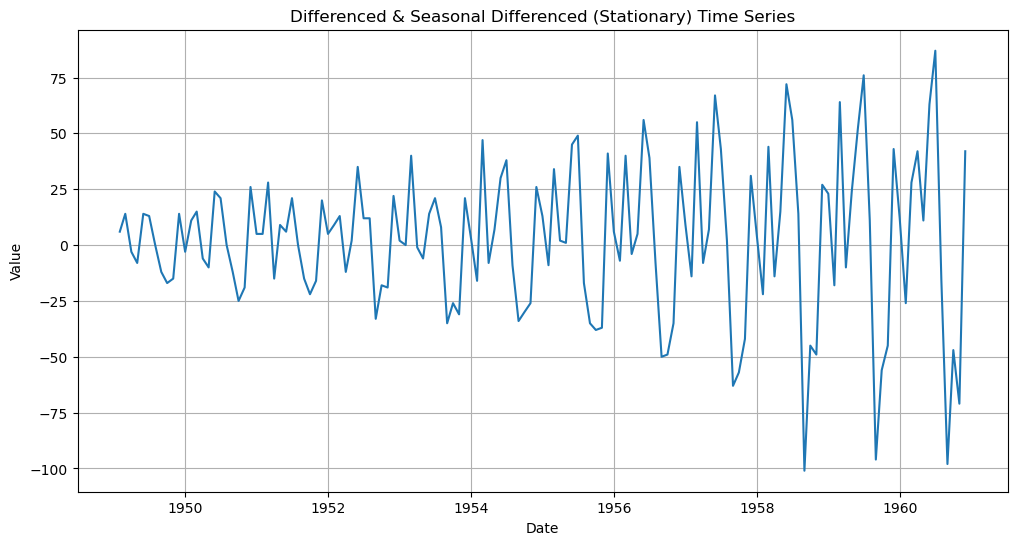

In [16]:
# --- Section 4: Re-testing the Differenced Series ---
# Now, let's plot the new series and run the tests again to confirm stationarity.
print("Plotting the differenced series...")
plt.figure(figsize=(12, 6))
plt.plot(differenced_series)
plt.title('Differenced & Seasonal Differenced (Stationary) Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()

In [17]:
check_stationarity(differenced_series, 'Differenced & Seasonal Differenced')


--- Results for the Differenced & Seasonal Differenced series ---
ADF Test:
  Test Statistic: -2.8293
  P-value: 0.0542
  Interpretation:
  --> Fails to reject H0. The series is likely non-stationary.

KPSS Test:
  Test Statistic: 0.0239
  P-value: 0.1000
  Interpretation:
  --> Fails to reject H0. The series is likely stationary.


Text(0.5, 0.98, 'ACF and PACF of Original Non-Stationary Series')

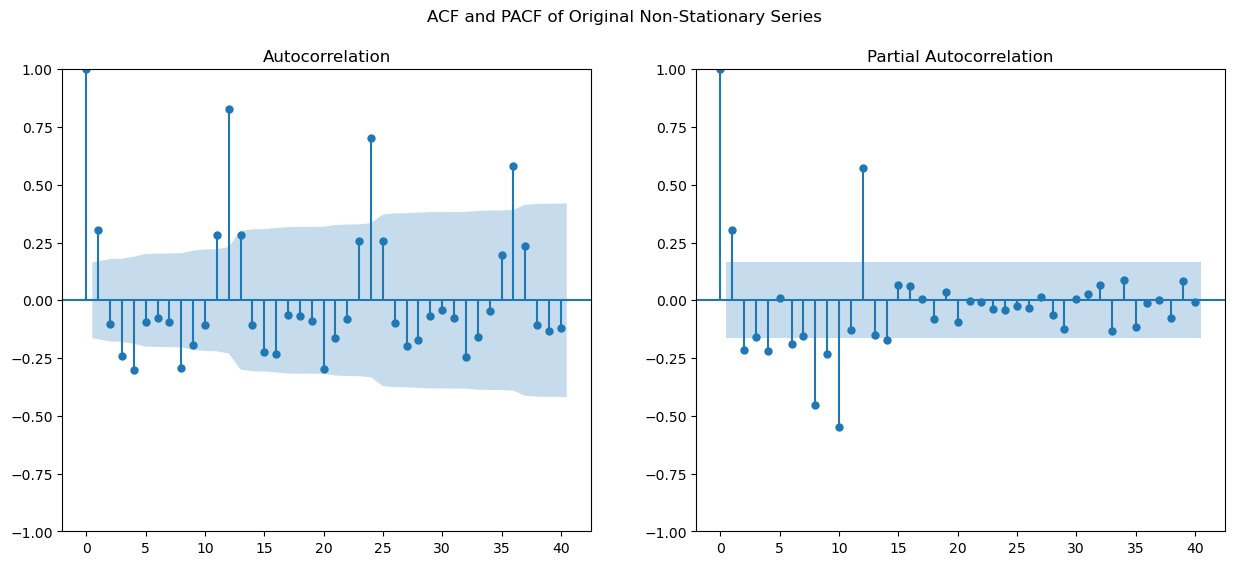

In [18]:
# Plot for the original, non-stationary series
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_acf(differenced_series, ax=axes[0], lags=40)
plot_pacf(differenced_series, ax=axes[1], lags=40)
fig.suptitle('ACF and PACF of Original Non-Stationary Series')

In [19]:
# Second, apply a seasonal difference (lag=12 for monthly data)
# to remove the seasonality from the detrended series.
print("Applying a seasonal differencing to remove seasonality...")
differenced_series_seasonal = differenced_series.diff(periods=12).dropna()

Applying a seasonal differencing to remove seasonality...


Plotting the differenced and seasonal differenced series...


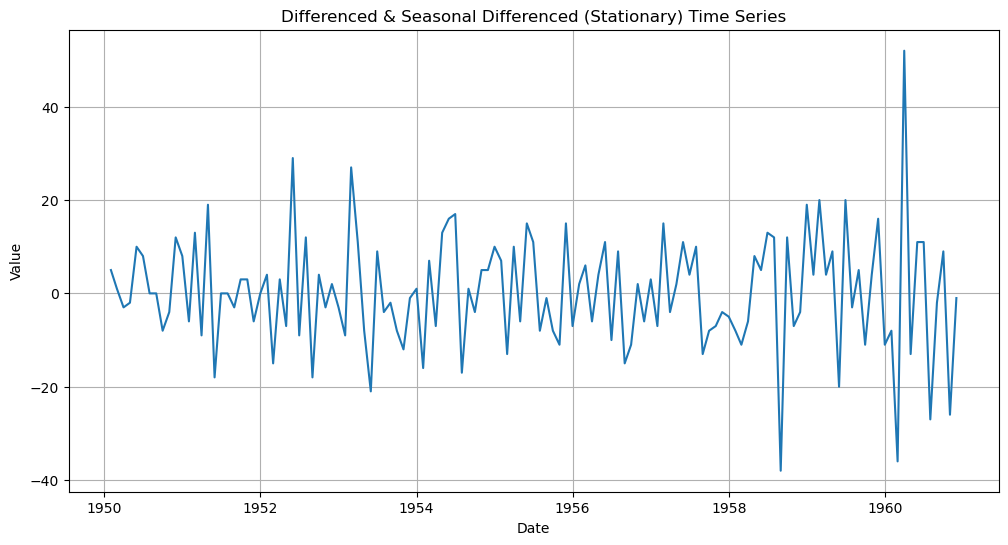

In [20]:
# --- Section 4: Re-testing the Differenced Series ---
# Now, let's plot the new series and run the tests again to confirm stationarity.
print("Plotting the differenced and seasonal differenced series...")
plt.figure(figsize=(12, 6))
plt.plot(differenced_series_seasonal)
plt.title('Differenced & Seasonal Differenced (Stationary) Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()

In [21]:
check_stationarity(differenced_series_seasonal, 'Differenced & Seasonal Differenced')


--- Results for the Differenced & Seasonal Differenced series ---
ADF Test:
  Test Statistic: -15.5956
  P-value: 0.0000
  Interpretation:
  --> Rejects H0. The series is likely stationary.

KPSS Test:
  Test Statistic: 0.0468
  P-value: 0.1000
  Interpretation:
  --> Fails to reject H0. The series is likely stationary.


Text(0.5, 0.98, 'ACF and PACF of Original Non-Stationary Series')

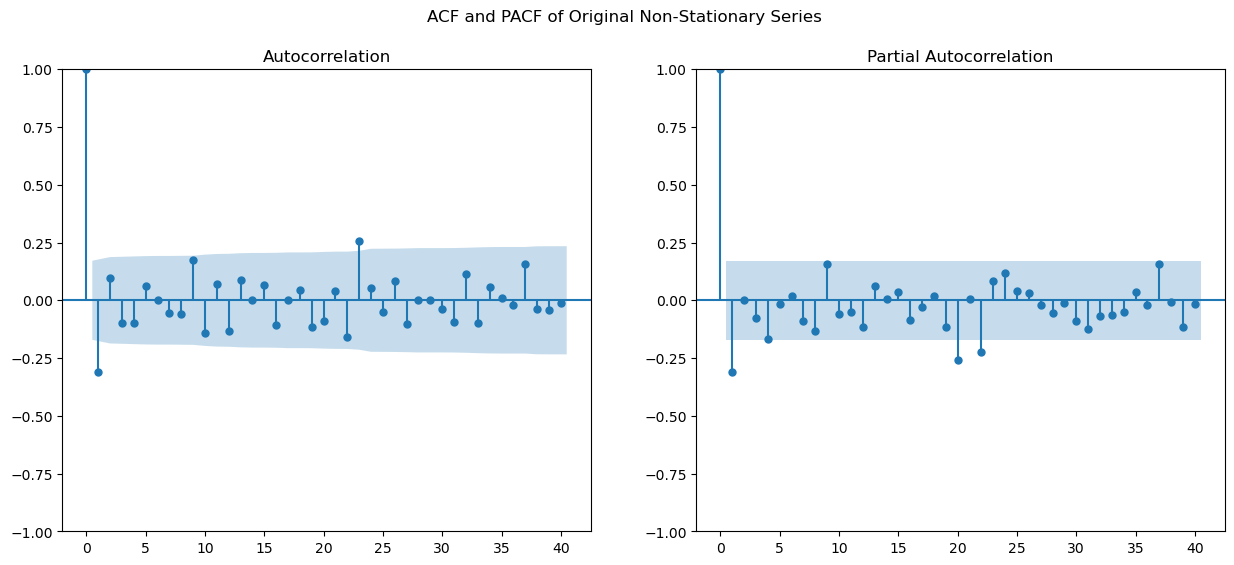

In [22]:
# Plot for the original, non-stationary series
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_acf(differenced_series_seasonal, ax=axes[0], lags=40)
plot_pacf(differenced_series_seasonal, ax=axes[1], lags=40)
fig.suptitle('ACF and PACF of Original Non-Stationary Series')